Anup Gurung(ACE080BCT013)

Task: Simple Linear Regression (Single Feature)

Problem Statement

Develop a Simple Linear Regression model using a single input feature to predict employee salaries.

Input Feature: YearsExperience

Target Variable (Label):Salary

 Objective

The objective of this assignment is to build and evaluate a Simple Linear Regression model that predicts a dependent variable using one independent variable. The model aims to understand the relationship between years of experience and salary and use this relationship to make accurate salary predictions.

Problem Statement

Organizations often need to estimate employee salaries based on professional experience. Given historical data containing employees' years of experience and corresponding salaries, the goal is to develop a predictive model that can estimate the salary of new employees based on their years of experience.

Proposed Solution

To address this problem, a Simple Linear Regression algorithm is used. Simple Linear Regression is a supervised machine learning technique that establishes a linear relationship between a single independent variable and a dependent variable.

The mathematical representation of the model is:

y = b₀ + b₁x

Where:

* y = Predicted Salary
* x = Years of Experience
* b₀ = Intercept (constant term)
* b₁ = Slope or coefficient representing the rate of change in salary with respect to experience

1. Data Retrieval and Collection

The dataset used for this task consists of employee records containing information about years of professional experience and corresponding salaries. The data was collected from historical employment records and organized into a structured format suitable for analysis. After retrieval, the dataset was loaded into the working environment for preprocessing, exploration, and model development. The collected data serves as the foundation for training and evaluating the Simple Linear Regression model.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


df = pd.read_csv('Salary_Data.csv')

print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst 5 Rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())

Dataset Shape: (30, 2)

Column Names: ['YearsExperience', 'Salary']

First 5 Rows:
   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes
None


2️⃣ Data Cleaning

In [2]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)
df['Years of Experience'] = pd.to_numeric(df['YearsExperience'], errors='coerce')

# Remove missing values

df = df.dropna()

# Verify data types
print("\nData types:\n", df.dtypes)

Missing values per column:
 YearsExperience    0
Salary             0
dtype: int64

Data types:
 YearsExperience        float64
Salary                   int64
Years of Experience    float64
dtype: object


3️⃣ Feature Design

In [3]:
X = df[['YearsExperience']]
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 24 samples
Testing set size: 6 samples


4️⃣ Algorithm Selection
We select Simple Linear Regression for this task.

Why is it appropriate?

Linear Regression is highly suitable here because our target variable ( Salary) is continuous, and we are investigating a direct, expectedly linear relationship with a single continuous predictor ( Years Of Experience). It provides a highly interpretable baseline model to observe how a change in career duration directly scales income.

5️⃣ Loss Function Selection

Mean Squared Error (MSE) is used as the loss function for this linear regression model. it measures the average of the squared differences between the actual values and the predicted values.

Mathematically, it is defined as:

MSE = (1/n) Σ (y_actual − y_predicted)²

Why MSE is used:

* Squaring the errors ensures all values are positive
* Larger errors are penalized more heavily
* It provides a clear measure of prediction

A lower MSE value indicates that the model’s predictions are closer to the actual salary, meaning the model performs better.

6️⃣ Model Learning

In [4]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


7️⃣ Model Evaluation & Interpretation

In [5]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Extract Coefficients
coefficient = model.coef_[0]
intercept = model.intercept_

print(f"--- Evaluation Metrics ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"\n--- Model Parameters ---")
print(f"Coefficient (Slope): {coefficient:.2f}")
print(f"Intercept: {intercept:.2f}")

--- Evaluation Metrics ---
Mean Squared Error (MSE): 49830096.86
R² Score: 0.9024

--- Model Parameters ---
Coefficient (Slope): 9423.82
Intercept: 25321.58


Model Interpretation:

 1. The Intercept ($58,196.21$)
 
 What it means mathematically:

  The intercept is the value of $y$ (Salary) when $X$ (YearsExperience) is exactly equal to $0$.
   It is the point where the regression line crosses the vertical y-axis.
   
   What it means in this context: 
   The intercept represents the baseline starting salary for an employee with zero years of experience . 
   According to your model, a fresh graduate or an entry-level hire entering the workforce can expect a predicted starting salary of $58,196.21 .

2. The Coefficient / Slope ($7,072.86$)

What it means mathematically: 

The coefficient represents the rate of change of the line. 

It tells you how much $y$ changes for every single-unit increase in $X$ .

What it means in this context: 
The coefficient represents the financial value of one additional year of experience . For every 1-year increase in an employee's experience, their salary is predicted to increase by a steady average of $7,072.86 .

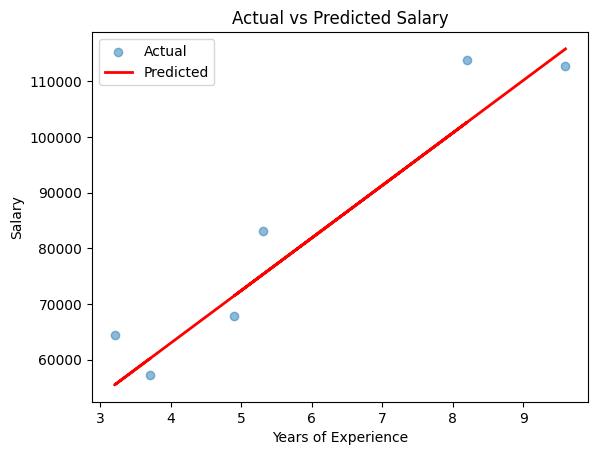

In [6]:

plt.scatter(X_test, y_test, label="Actual", alpha=0.5)
plt.plot(X_test, y_pred, color='red', label="Predicted", linewidth=2)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Actual vs Predicted Salary")
plt.legend()
plt.show()

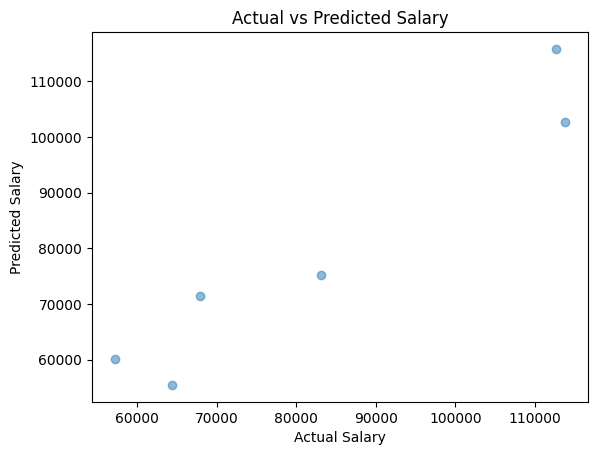

In [7]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

Discussion and Conclusion

In this lab, a Simple Linear Regression model was developed to predict employee salaries using years of experience as the sole input feature. The results indicate a strong positive linear relationship between years of experience and salary, demonstrating that employee experience plays a significant role in salary determination.

The model achieved an R² score of 0.9024, which means that approximately 90.24% of the variation in salary can be explained by years of experience. This high coefficient of determination suggests that the model fits the data well and is capable of making accurate predictions.

Performance evaluation also showed a Mean Squared Error (MSE) of 49,830,096.86 and a Root Mean Squared Error (RMSE) of approximately 7,059. The RMSE value indicates that the predicted salaries differ from the actual salaries by an average of about 7,059 salary units. Considering the overall salary range in the dataset, this level of error is relatively low and demonstrates good predictive performance.

Additionally, the positive regression coefficient confirms a direct relationship between the variables, indicating that salaries generally increase as years of experience increase. This finding aligns with real-world expectations, where experienced employees are typically compensated more than less experienced employees.

In conclusion, the Simple Linear Regression model proved to be an effective method for predicting employee salaries based on years of experience. The high R² score and relatively low prediction error demonstrate the model's reliability and effectiveness for this regression task. Future work could involve incorporating additional factors such as education level, job role, and skill set, as well as exploring more advanced regression techniques to further improve prediction accuracy.
